In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("EmployeeAttrition.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [7]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8
1469,34,0,Travel_Rarely,628,Research & Development,8,3,Medical,2,Male,...,3,1,0,6,3,4,4,3,1,2


In [12]:
X = df.drop("Attrition", axis=1) 
y = df["Attrition"]

In [8]:
df.drop('Over18',axis=1,inplace=True)

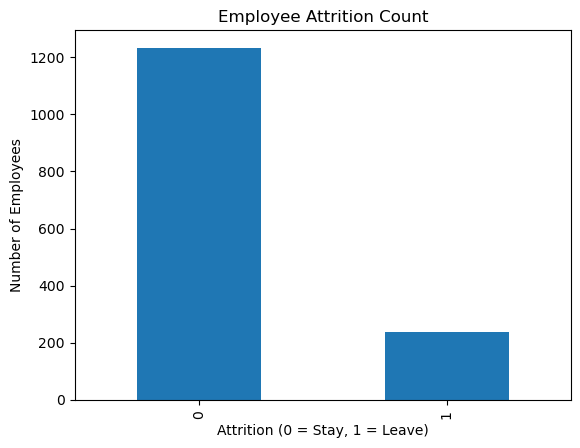

In [ ]:
df['Attrition'].value_counts().plot(kind='bar')
plt.title("Employee Attrition Count")
plt.xlabel('Attrition (0 = Stay, 1 = Leave)')
plt.ylabel('Number of Employees')
plt.show()

insight:- 
Out of 1470 employees, 237 employees left the company

Majority stayed, but company still has a retention issue

Does salary affect attrition?

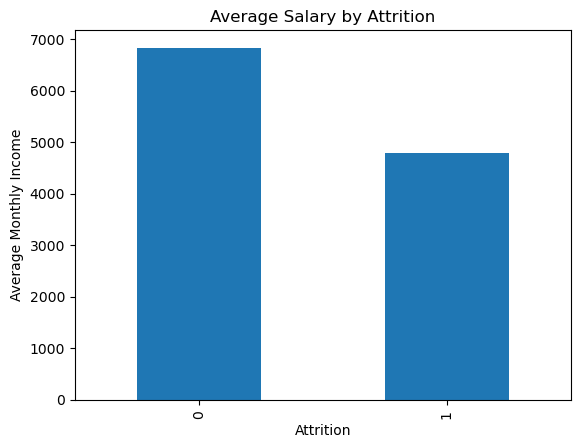

In [31]:
df.groupby('Attrition')['MonthlyIncome'].mean().plot(kind='bar')
plt.title('Average Salary by Attrition')
plt.ylabel('Average Monthly Income')
plt.show()

insight:-
-Employees who left earn much lower salary (~4800 vs ~6800)


-Low salary is a strong reason for attrition

Does age matter

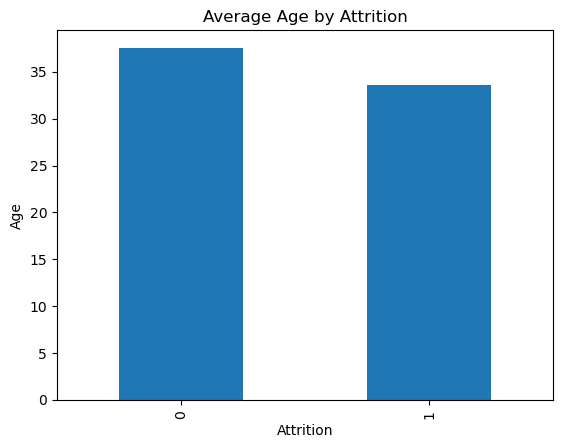

In [32]:
df.groupby('Attrition')['Age'].mean().plot(kind='bar')
plt.title('Average Age by Attrition')
plt.ylabel('Age')
plt.show()

insight:-
-Younger employees switch jobs more frequently.

does over time affect attrition

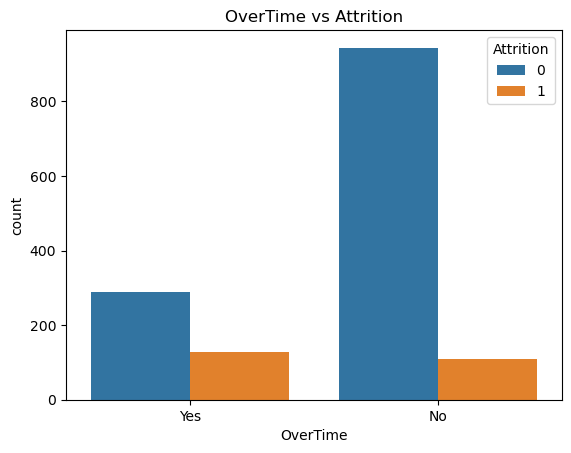

In [35]:
pd.crosstab(df['OverTime'],df['Attrition'],normalize='index')
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('OverTime vs Attrition')
plt.show()

insight:-
employees working overtime are more likely to leave

which dept. has highest attrition

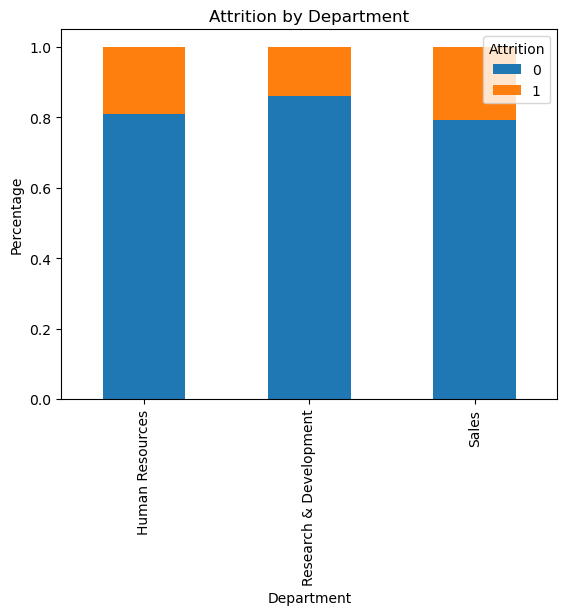

In [39]:
pd.crosstab(df['Department'],df['Attrition'],normalize='index').plot(kind='bar', stacked=True)
plt.title('Attrition by Department')
plt.ylabel('Percentage')
plt.show()

insight:-Sales department has highest attrition (~20%)
R&D has lowest → more stable.
Sales roles are more stressful

job satisfaction impact

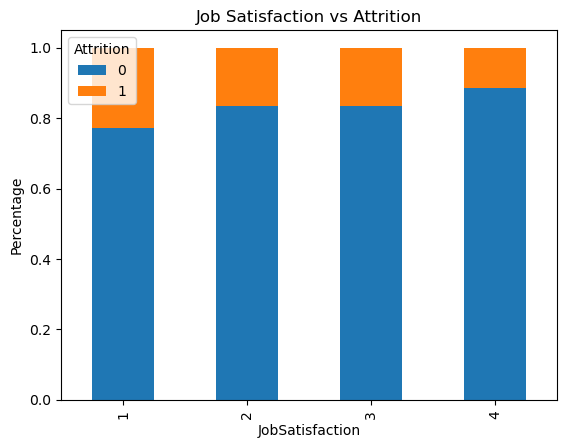

In [40]:
pd.crosstab(df['JobSatisfaction'],df['Attrition'],normalize='index').plot(kind='bar', stacked=True)
plt.title('Job Satisfaction vs Attrition')
plt.ylabel('Percentage')
plt.show()

insight:-Low satisfaction → higher attrition.
High satisfaction → employees stay.
Satisfaction directly affects retention

work life balance

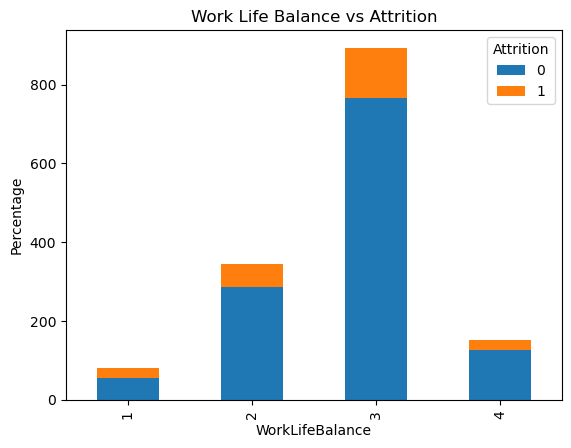

In [41]:
pd.crosstab(df['WorkLifeBalance'],df['Attrition']).plot(kind='bar', stacked=True)
plt.title('Work Life Balance vs Attrition')
plt.ylabel('Percentage')
plt.show()

insight:-Poor work-life balance → more employees leave.
Balance is critical for retention

does marital status affect attrition

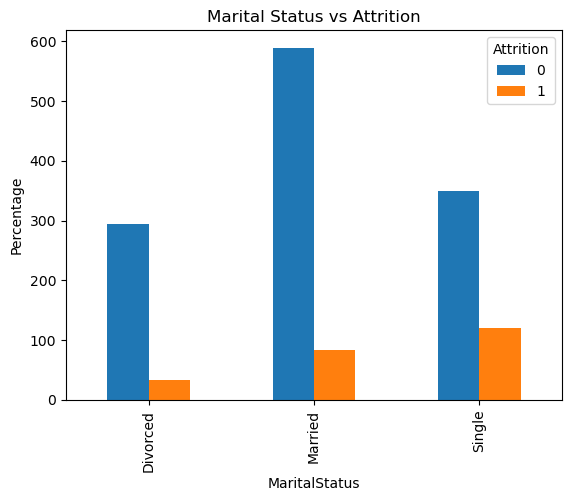

In [42]:
pd.crosstab(df['MaritalStatus'],df['Attrition']).plot(kind='bar')
plt.title('Marital Status vs Attrition')
plt.ylabel('Percentage')
plt.show()

insight:-Single employees leave the most
Married employees are more stable.
 Personal life stability impacts job retention

which job role people leaves more

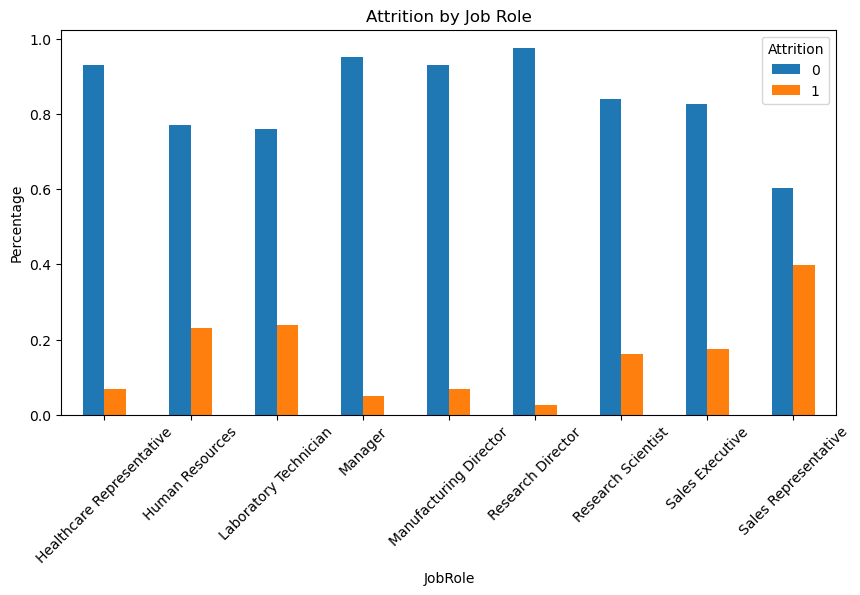

In [43]:
pd.crosstab(df['JobRole'],df['Attrition'],normalize='index').plot(kind='bar', figsize=(10,5))
plt.title('Attrition by Job Role')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

insight:-Sales Representatives have highest attrition (~39%)
Lab Technicians also high.
Managers & Directors → very low attrition.
Lower-level + high-pressure roles leave more.

Key Insights


- Around 237 employees out of 1470 employees left the company
- Lower salary strongly contributes to attrition
- Younger employees are more likely to leave
- Overtime significantly increases attrition
- Sales department shows highest attrition
- Low job satisfaction leads to higher attrition
- Poor work-life balance increases attrition
- Single employees leave more than married
- Sales Representatives have highest attrition